# Principal Component Analysis (PCA): Theory, Geometry & Implementation

## What is PCA?

PCA is an **unsupervised linear dimensionality reduction** technique. It finds a new orthogonal coordinate system (the **principal components**) such that:

1. **PC1** points in the direction of **maximum variance** in the data.
2. **PC2** points in the direction of the next highest variance, **orthogonal** to PC1.
3. And so on...

### Why Use PCA?
- **Visualization**: Project high-dimensional data down to 2D or 3D.
- **Compression**: Represent data with fewer dimensions while preserving most variance.
- **Denoising**: Discard low-variance components that often capture noise.
- **Decorrelation**: Remove multicollinearity before feeding data to linear models.

### The Mathematics
Given centered data matrix $X \in \mathbb{R}^{n \times p}$:

1. Compute the covariance matrix: $\Sigma = \frac{1}{n-1} X^T X$
2. Eigendecompose: $\Sigma v = \lambda v$
3. Sort eigenvectors by descending eigenvalue.
4. Project: $Z = X V_k$ where $V_k$ contains the top $k$ eigenvectors.

Equivalently, PCA can be computed via **SVD** of the centered data: $X = U S V^T$, where columns of $V$ are the principal components.


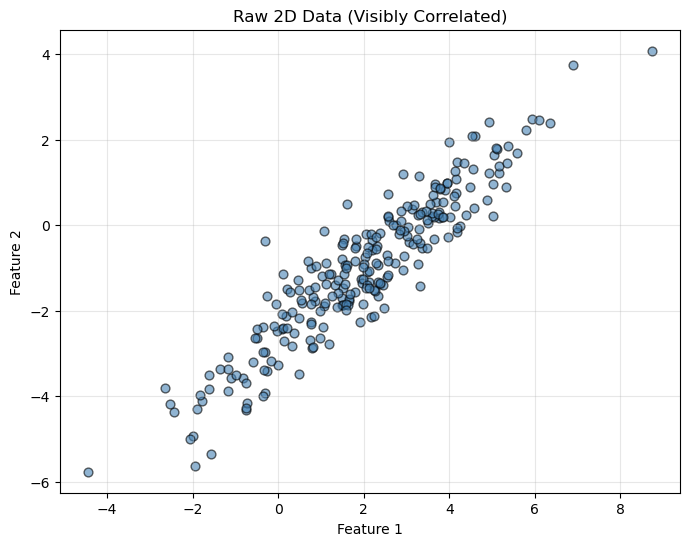

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Generate 2D correlated data
mean2 = [2, -1]
cov2 = [[4, 3.2], [3.2, 3]]
X2 = np.random.multivariate_normal(mean2, cov2, 250)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X2[:, 0], X2[:, 1], c='steelblue', edgecolors='k', alpha=0.6, s=40)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Raw 2D Data (Visibly Correlated)')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


## 1. Centering and Eigendecomposition

PCA is **translation-invariant** — we first center the data by subtracting the mean of each feature. Then we compute the covariance matrix and extract its eigenvectors.

The eigenvectors of the covariance matrix are the **principal directions**. The eigenvalues tell us how much variance each direction captures.

> **Key insight:** The covariance matrix is symmetric, so its eigenvectors are guaranteed to be orthogonal.


Eigenvalues (variances along PCs): [6.7091 0.2439]
Eigenvectors (columns = PCs):
[[-0.7612  0.6485]
 [-0.6485 -0.7612]]


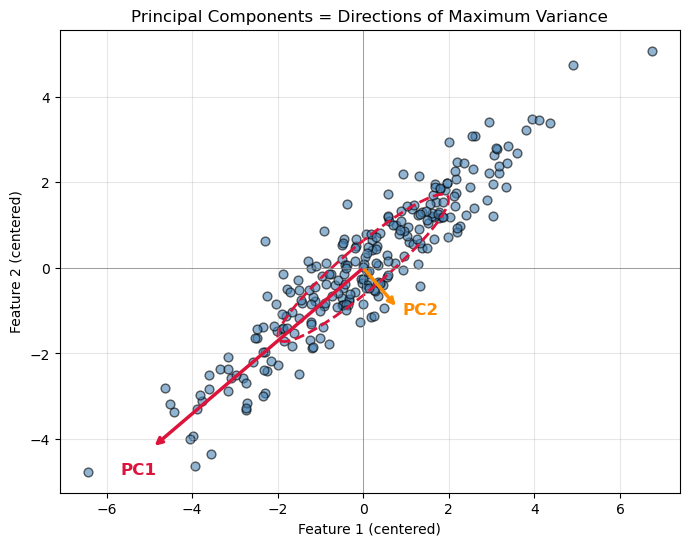

In [15]:
# Center the data
X2_mean = X2.mean(axis=0)
X2c = X2 - X2_mean

# Covariance matrix
cov2 = np.cov(X2c, rowvar=False)

# Eigendecomposition (eigh is numerically stable for symmetric matrices)
eigvals, eigvecs = np.linalg.eigh(cov2)

# Sort descending
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print("Eigenvalues (variances along PCs):", np.round(eigvals, 4))
print("Eigenvectors (columns = PCs):")
print(np.round(eigvecs, 4))

# Plot centered data with principal components
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X2c[:, 0], X2c[:, 1], c='steelblue', edgecolors='k', alpha=0.6, s=40, label='Centered data')

# Draw eigenvectors scaled by standard deviation
scale = 2.5
for i in range(2):
    vec = eigvecs[:, i] * np.sqrt(eigvals[i]) * scale
    ax.annotate('', xy=(vec[0], vec[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='crimson' if i == 0 else 'darkorange', lw=2.5))
    ax.text(vec[0]*1.15, vec[1]*1.15, 'PC' + str(i+1), color='crimson' if i == 0 else 'darkorange',
            fontsize=12, fontweight='bold')

# 1-sigma covariance ellipse
from matplotlib.patches import Ellipse
angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
ellipse = Ellipse(xy=(0, 0), width=2*np.sqrt(eigvals[0]), height=2*np.sqrt(eigvals[1]),
                  angle=angle, edgecolor='crimson', facecolor='none', linewidth=2, linestyle='--')
ax.add_patch(ellipse)

ax.set_xlabel('Feature 1 (centered)')
ax.set_ylabel('Feature 2 (centered)')
ax.set_title('Principal Components = Directions of Maximum Variance')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


## 2. Projection and Reconstruction

The projection of a data point $x$ onto the $j$-th principal component is called a **score**:

$$z_j = x^T v_j$$

If we keep only the top $k$ components, we can **reconstruct** an approximation:

$$\hat{x} = \bar{x} + \sum_{j=1}^{k} z_j v_j$$

The plots below show:
1. The original data.
2. The 1D approximation using only PC1 (with projection lines).
3. The data rotated into the PC coordinate system (decorrelated).

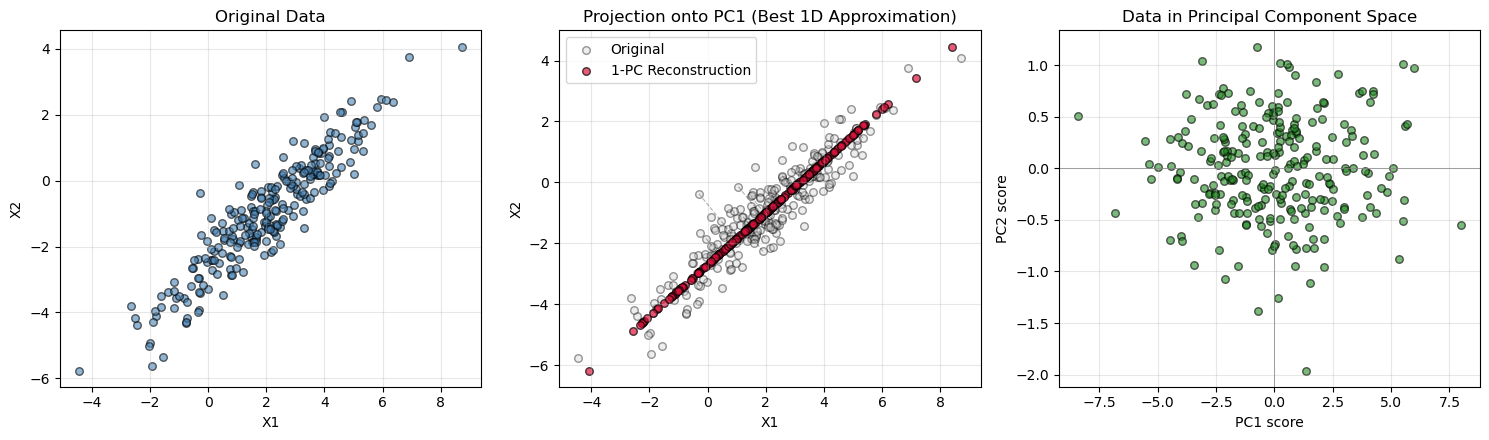

Reconstruction MSE using 1 PC: 0.1215
Reconstruction MSE using 2 PCs: 0.0000 (perfect)


In [16]:
# Project onto PC1
pc1 = eigvecs[:, 0]
scores_pc1 = X2c @ pc1

# Reconstruct using only PC1
X2_recon_1pc = np.outer(scores_pc1, pc1) + X2_mean

# Full rotation into PC space (scores on both PCs)
scores_full = X2c @ eigvecs

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Original
ax = axes[0]
ax.scatter(X2[:, 0], X2[:, 1], c='steelblue', edgecolors='k', alpha=0.6, s=30)
ax.set_title('Original Data')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.grid(True, alpha=0.3)

# 1D reconstruction with projection lines
ax = axes[1]
ax.scatter(X2[:, 0], X2[:, 1], c='lightgray', edgecolors='k', alpha=0.4, s=30, label='Original')
ax.scatter(X2_recon_1pc[:, 0], X2_recon_1pc[:, 1], c='crimson', edgecolors='k', alpha=0.7, s=30, label='1-PC Reconstruction')

for i in range(0, len(X2), 8):
    ax.plot([X2[i, 0], X2_recon_1pc[i, 0]], [X2[i, 1], X2_recon_1pc[i, 1]],
            'k--', alpha=0.3, lw=0.8)

ax.set_title('Projection onto PC1 (Best 1D Approximation)')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.legend()
ax.grid(True, alpha=0.3)

# PC space (decorrelated)
ax = axes[2]
ax.scatter(scores_full[:, 0], scores_full[:, 1], c='forestgreen', edgecolors='k', alpha=0.6, s=30)
ax.set_xlabel('PC1 score')
ax.set_ylabel('PC2 score')
ax.set_title('Data in Principal Component Space')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

recon_err_1pc = np.mean((X2 - X2_recon_1pc)**2)
print("Reconstruction MSE using 1 PC: {0:.4f}".format(recon_err_1pc))
print("Reconstruction MSE using 2 PCs: 0.0000 (perfect)")


## 3. Explained Variance

Each eigenvalue $\lambda_j$ represents the variance captured by PC $j$. The **explained variance ratio** is:

$$\text{Ratio}_j = \frac{\lambda_j}{\sum_{i=1}^{p} \lambda_i}$$

The **cumulative explained variance** tells us how many components we need to retain a given percentage of total information. This is the primary tool for choosing the target dimensionality $k$.


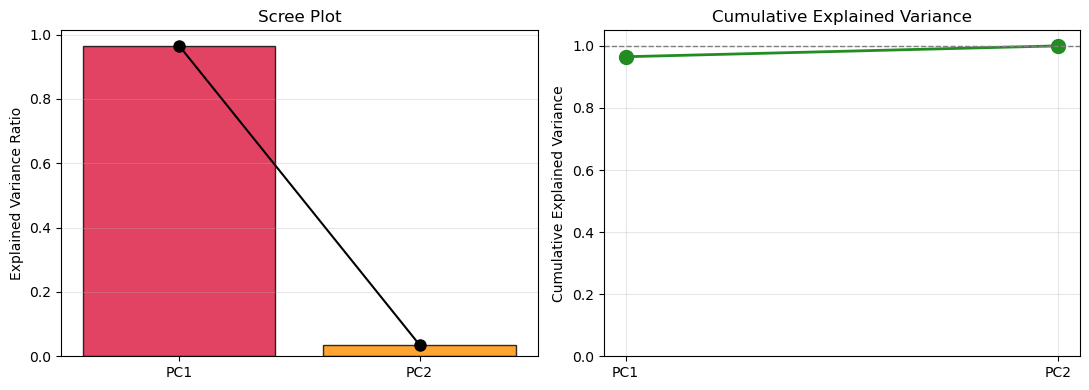

Explained variance ratios:
  PC1: 0.9649 (96.5%)
  PC2: 0.0351 (3.5%)


In [17]:
explained_ratio = eigvals / np.sum(eigvals)
cumulative = np.cumsum(explained_ratio)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Scree plot
ax = axes[0]
comps = [1, 2]
ax.bar(comps, explained_ratio, color=['crimson', 'darkorange'], edgecolor='black', alpha=0.8)
ax.plot(comps, explained_ratio, 'ko-', markersize=8)
ax.set_xticks(comps)
ax.set_xticklabels(['PC1', 'PC2'])
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot')
ax.grid(True, alpha=0.3, axis='y')

# Cumulative
ax = axes[1]
ax.plot(comps, cumulative, 'o-', color='forestgreen', markersize=10, linewidth=2)
ax.axhline(1.0, color='gray', linestyle='--', lw=1)
ax.set_xticks(comps)
ax.set_xticklabels(['PC1', 'PC2'])
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Explained Variance')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Explained variance ratios:")
print("  PC1: {0:.4f} ({1:.1f}%)".format(explained_ratio[0], explained_ratio[0]*100))
print("  PC2: {0:.4f} ({1:.1f}%)".format(explained_ratio[1], explained_ratio[1]*100))


## 4. PCA via Singular Value Decomposition (SVD)

For numerical stability, especially in high dimensions, PCA is typically implemented via SVD rather than explicit eigendecomposition of the covariance matrix.

If $X = U S V^T$ is the (centered) data, then:

- Columns of $V$ are the **principal components** (eigenvectors of $X^T X$).
- $S^2 / (n-1)$ gives the **eigenvalues** (variances).
- $U S$ gives the **scores** (projections).

SVD avoids explicitly forming $X^T X$, which can amplify numerical errors.


In [18]:
# SVD on centered 2D data
U, S, Vt = np.linalg.svd(X2c, full_matrices=False)

# Recover eigenvalues and vectors
eigvals_svd = (S**2) / (X2c.shape[0] - 1)
eigvecs_svd = Vt.T

print("=== Eigendecomposition vs SVD ===")
print("Eigenvalues (eig):", np.round(eigvals, 4))
print("Eigenvalues (svd):", np.round(eigvals_svd, 4))
print("Eigenvectors match (up to sign):", np.allclose(np.abs(eigvecs), np.abs(eigvecs_svd), atol=1e-6))

# Reconstruct using SVD with 1 component
k = 1
X2_recon_svd = (U[:, :k] * S[:k]) @ Vt[:k, :] + X2_mean
print("Reconstruction MSE (SVD, 1 PC): {0:.4f}".format(np.mean((X2 - X2_recon_svd)**2)))


=== Eigendecomposition vs SVD ===
Eigenvalues (eig): [6.7091 0.2439]
Eigenvalues (svd): [6.7091 0.2439]
Eigenvectors match (up to sign): True
Reconstruction MSE (SVD, 1 PC): 0.1215


## 5. Higher-Dimensional Example

In higher dimensions, the scree plot reveals how many latent dimensions actually matter. We generate 8D data driven by only 3 underlying factors plus noise.

The scree plot should show an "elbow" after the 3rd component, and the cumulative curve tells us exactly how many components to keep for, say, 90% variance retention.


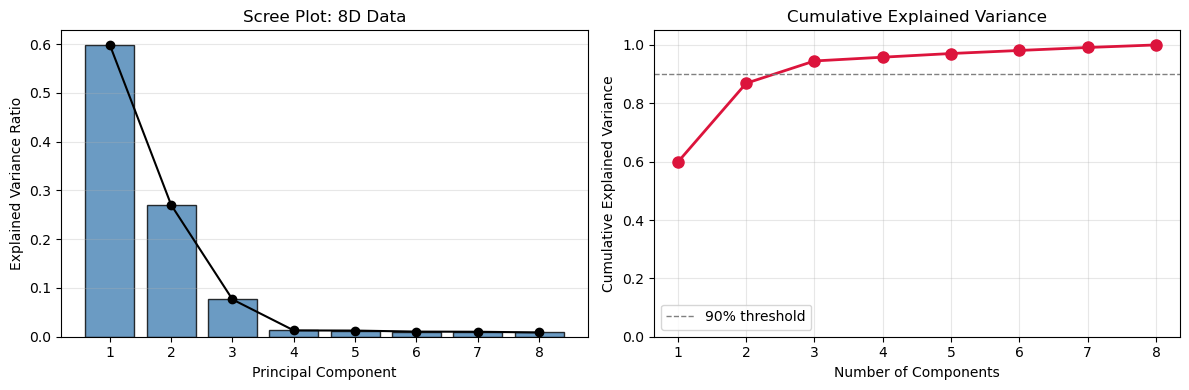

Components needed for 90% variance: 3


In [19]:
# 8D data with only 3 true latent factors
np.random.seed(7)
n_samples = 300
n_features = 8

true_comps = np.random.randn(n_features, 3)
latent = np.random.randn(n_samples, 3)
X_high = latent @ true_comps.T + np.random.randn(n_samples, n_features) * 0.5

Xh_mean = X_high.mean(axis=0)
Xhc = X_high - Xh_mean

# PCA via SVD
U_h, S_h, Vt_h = np.linalg.svd(Xhc, full_matrices=False)
eigvals_h = (S_h**2) / (n_samples - 1)
explained_h = eigvals_h / np.sum(eigvals_h)
cumulative_h = np.cumsum(explained_h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree
ax = axes[0]
x_pos = np.arange(1, n_features + 1)
ax.bar(x_pos, explained_h, color='steelblue', edgecolor='black', alpha=0.8)
ax.plot(x_pos, explained_h, 'ko-', markersize=6)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot: 8D Data')
ax.grid(True, alpha=0.3, axis='y')

# Cumulative
ax = axes[1]
ax.plot(x_pos, cumulative_h, 'o-', color='crimson', markersize=8, linewidth=2)
ax.axhline(0.9, color='gray', linestyle='--', lw=1, label='90% threshold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('Cumulative Explained Variance')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_90 = int(np.argmax(cumulative_h >= 0.9) + 1)
print("Components needed for 90% variance:", n_90)


## 6. Dimensionality Reduction: 3D to 2D

When data lives close to a lower-dimensional subspace, PCA finds that subspace and projects onto it. Below, 3D data is mostly flat (two large eigenvalues, one tiny). Projecting to the top-2 PC plane preserves almost all information.

This is the geometric essence of PCA: find the best-fitting low-dimensional affine subspace and orthogonally project the data onto it.


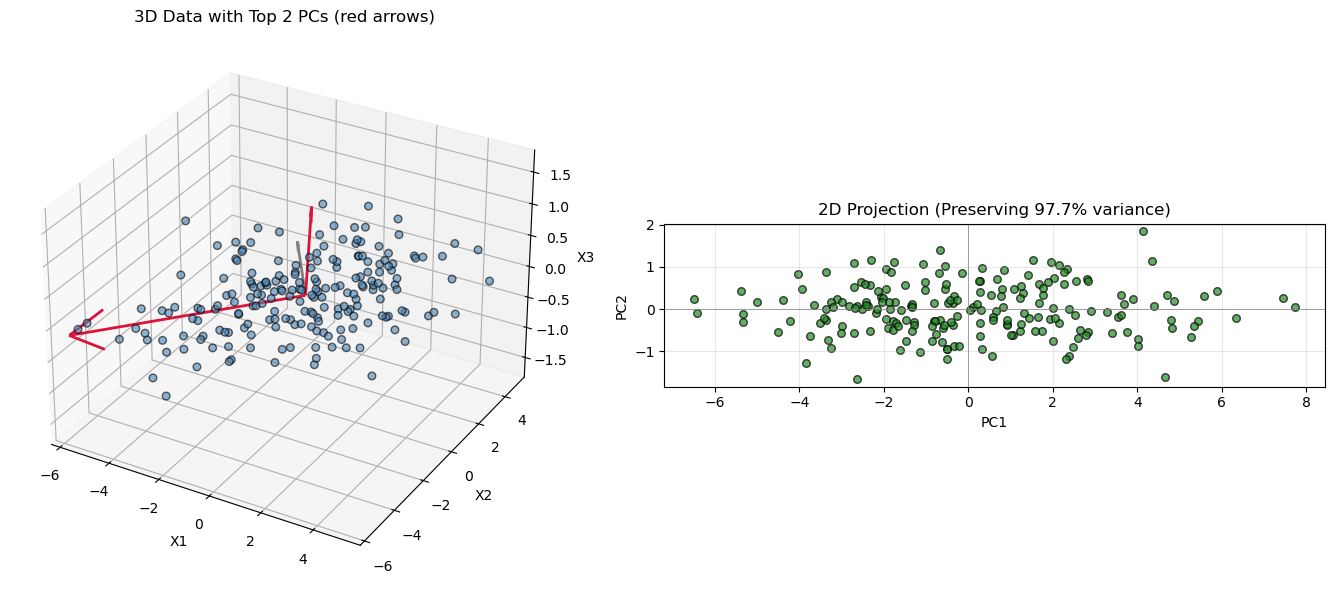

3D Eigenvalues: [7.4072 0.3591 0.1807]
Variance preserved in 2D: 97.73%


In [20]:
# 3D data: mostly 2D plane plus small noise in Z
np.random.seed(3)
mean3 = [0, 0, 0]
cov3 = [[4, 3.8, 0.2], [3.8, 4, 0.1], [0.2, 0.1, 0.3]]
X3 = np.random.multivariate_normal(mean3, cov3, 200)

X3_mean = X3.mean(axis=0)
X3c = X3 - X3_mean

# PCA
eig3, vec3 = np.linalg.eigh(np.cov(X3c, rowvar=False))
order3 = eig3.argsort()[::-1]
eig3 = eig3[order3]
vec3 = vec3[:, order3]

# Project to 2D
X3_proj2d = X3c @ vec3[:, :2]

fig = plt.figure(figsize=(14, 6))

# 3D original with PCs
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2], c='steelblue', edgecolors='k', alpha=0.6, s=30)

scale3 = 3
for i in range(3):
    v = vec3[:, i] * np.sqrt(eig3[i]) * scale3
    ax1.quiver(0, 0, 0, v[0], v[1], v[2],
               color='crimson' if i < 2 else 'gray',
               arrow_length_ratio=0.15, linewidth=2)

ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_zlabel('X3')
ax1.set_title('3D Data with Top 2 PCs (red arrows)')

# 2D projection
ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X3_proj2d[:, 0], X3_proj2d[:, 1], c='forestgreen', edgecolors='k', alpha=0.7, s=30)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
var_preserved = (eig3[0] + eig3[1]) / np.sum(eig3) * 100
ax2.set_title('2D Projection (Preserving ' + '{0:.1f}'.format(var_preserved) + '% variance)')
ax2.axhline(0, color='gray', lw=0.5)
ax2.axvline(0, color='gray', lw=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

print("3D Eigenvalues:", np.round(eig3, 4))
print("Variance preserved in 2D: {0:.2f}%".format(var_preserved))


## 7. Reconstruction Error vs Number of Components

As we include more principal components, the reconstruction error drops. The curve is monotonically decreasing and flattens once the remaining components capture only noise.

This tradeoff curve is the empirical justification for choosing a truncation point $k$.


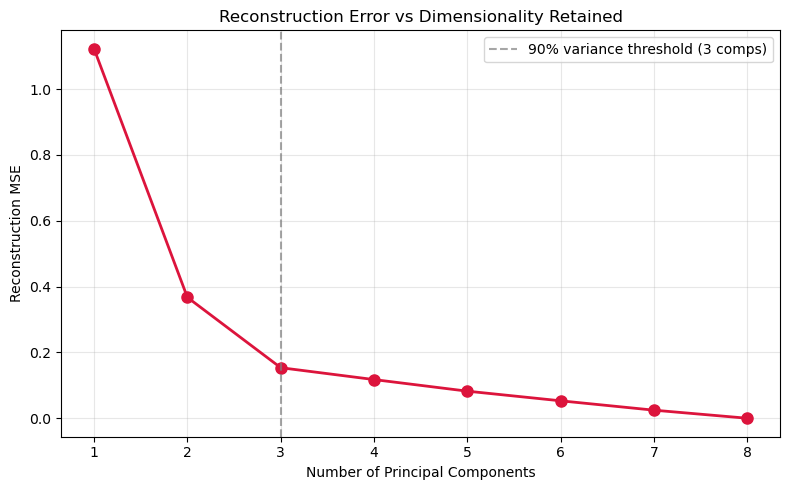

Reconstruction MSE by number of components:
  k=1: 1.1223
  k=2: 0.3672
  k=3: 0.1536
  k=4: 0.1175
  k=5: 0.0822
  k=6: 0.0530
  k=7: 0.0245
  k=8: 0.0000


In [21]:
# Reconstruction error vs k for the 8D data
recon_mse = []
for k in range(1, n_features + 1):
    X_k = (U_h[:, :k] * S_h[:k]) @ Vt_h[:k, :] + Xh_mean
    mse = np.mean((X_high - X_k)**2)
    recon_mse.append(mse)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, n_features + 1), recon_mse, 'o-', color='crimson', markersize=8, linewidth=2)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Reconstruction MSE')
ax.set_title('Reconstruction Error vs Dimensionality Retained')
ax.grid(True, alpha=0.3)

# Mark 90% variance threshold
ax.axvline(n_90, color='gray', linestyle='--', alpha=0.7,
           label='90% variance threshold (' + str(n_90) + ' comps)')
ax.legend()
plt.tight_layout()
plt.show()

print("Reconstruction MSE by number of components:")
for k, mse in enumerate(recon_mse, 1):
    print("  k={0}: {1:.4f}".format(k, mse))


## Summary

| Concept | Meaning |
|---------|---------|
| **Principal Component** | Direction of maximum variance; eigenvector of covariance matrix |
| **Score** | Projection of a data point onto a principal component |
| **Explained Variance Ratio** | Fraction of total variance captured by a single PC |
| **Cumulative Variance** | Running total; used to choose how many PCs to keep |
| **Reconstruction** | Approximating original data from a subset of PCs |

### Key Takeaways
- PCA is **linear**, **unsupervised**, and **orthogonal**.
- It is equivalent to eigendecomposition of the covariance matrix or SVD of the centered data matrix.
- The **scree plot** and **cumulative variance curve** are the standard tools for choosing the reduced dimensionality $k$.
- PCA removes correlation between features (the scores are decorrelated), which is useful as a preprocessing step for linear models, clustering, and visualization.